# COE 311K Final Project, Part 3

Individual project by Thomas Thomas (tlt2748)

## Review of Part 2

My system is the highly damped mechanical system. It has a stiffness parameter of $10^4$ (slow-moving time scale / fast-moving time scale), meaning the problem is stiff. Physically, this means the spring-damper system responds very quickly to fast transient forces while simultaneously following slow transient forces.

The solutions from part 2 utilize an implicit solver named Euler's Backward, which in turn used Newton-Raphson. Each fixed time step, it would evaluate a best-guess equation for the next y-value using Newton-Raphson, then use that best-guess future y-value to evaluate the differential equation at a future time (hence Euler's Backward), using that future-biased slope to retain accuracy given much larger step sizes than traditional explicit solvers like Euler's Forward.

## Newton-Raphson Damping Implementation

When regular Newton-Raphson isn't working very well, we can use a damping factor $\alpha$ to suppress large updates. This is useful when step size is too large, when the initial guess is unusually far off, or when the update overshoots and diverges.

The implementation of this is with a line search technique. Every time we call the Newton-Raphson function, we check if the residual decreases; otherwise, we double the damping effect (by halving $\alpha$) until it does (or until $\alpha$ becomes too small).

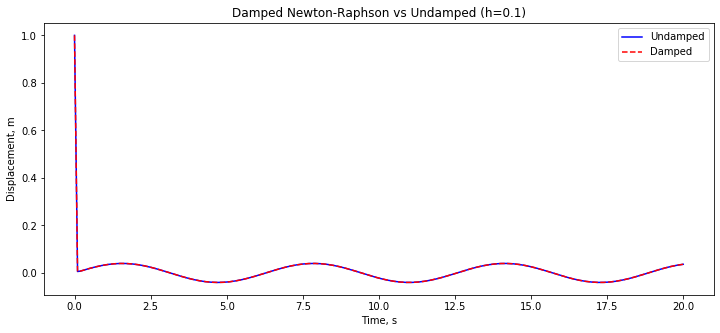

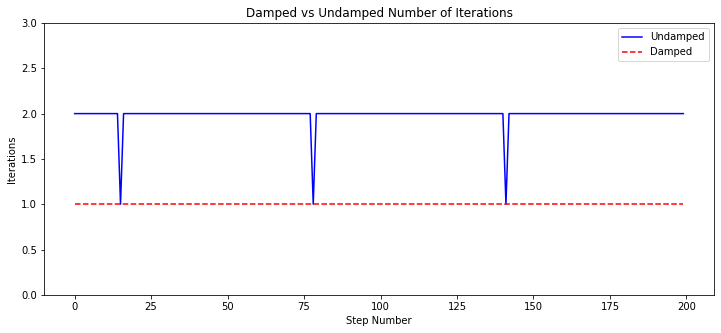

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# System Parameters
k = 5000 # N/m
c = 1 # Ns/m
t0 = 0 # s
tf = 20 # s
x0 = 1 # m

# System derivative function
f = lambda x, t: -(k/c)*x + 200*np.sin(t)/c

# Newton-Raphson internal derivative
g_prime = lambda h: 1 + h*(k/c)

### Methods

# Basic Newton-Raphson step
def nr_step_basic(f, x_n, t, h, tol=1e-4, iterations=50):
    x_n1 = x_n
    for i in range(1, iterations+1):
        g_val = x_n1 - x_n - h * f(x_n1, t+h)
        if abs(g_val) < tol:
            return x_n1, i, True
        delta = -g_val / g_prime(h)
        if abs(delta) < tol:
            return x_n1 + delta, i, True
        x_n1 += delta
    return x_n1, iterations, False

# Damped Newton-Raphson step
def nr_step_damped(f, x_n, t, h, tol=1e-4, iterations=50):
    x_n1 = x_n
    for i in range(1, iterations+1):
        g_val = x_n1 - x_n - h * f(x_n1, t+h)
        if abs(g_prime(h)) < tol:
            return x_n1, i, True
        
        # Line search
        alpha = 1.0
        delta = -g_val / g_prime(h)
        j = 0 # counter
        while True:
            j += 1
            x_new = x_n1 + alpha * delta
            g_new = abs(x_new - x_n - h * f(x_new, t+h))
            if g_new < abs(g_val):
                return x_new, i, True
            alpha /= 2
            if alpha < tol:
                break
        
        x_n1 = x_new
    return x_n1, iterations, False
        
# Basic Euler's Backward, can use either Newton-Raphson function
def euler_backward_basic(f, x0, t0, tf, h, nr_func, tol=1e-4, iterations=50):
    t_vals = np.arange(t0, tf+h, h)
    x_vals = np.zeros_like(t_vals)
    nr_iterations = np.zeros(t_vals.size-1)
    nr_convergence = np.zeros(t_vals.size-1)
    x_vals[0] = x0
    for i in range(len(t_vals)-1):
        x_vals[i+1], nr_iterations[i], nr_convergence[i] = nr_func(f, x_vals[i], t_vals[i], h, tol, iterations)
    return t_vals, x_vals, nr_iterations, nr_convergence

# Damping demonstration
h = 0.1
undamped = euler_backward_basic(f, x0, t0, tf, h, nr_step_basic)
damped   = euler_backward_basic(f, x0, t0, tf, h, nr_step_damped)

plt.figure(figsize=(12,5))
plt.plot(undamped[0], undamped[1], 'b-', label="Undamped")
plt.plot(damped[0], damped[1], 'r--', label="Damped")
plt.xlabel("Time, s")
plt.ylabel("Displacement, m")
plt.title(f"Damped Newton-Raphson vs Undamped (h={h})")
plt.legend()
plt.show()

# Iterations
plt.figure(figsize=(12,5))
plt.plot(range(len(undamped[2])), undamped[2], 'b-', label="Undamped")
plt.plot(range(len(damped[2])), damped[2], 'r--', label="Damped")
plt.xlabel("Step Number")
plt.ylabel("Iterations")
plt.ylim(0,3)
plt.title("Damped vs Undamped Number of Iterations")
plt.legend()
plt.show()

## Adaptive Step Size Implementation

The error in one full Newton-Raphson step can be estimated by taking two half-steps and comparing the result. The error can be used to adapt the step size to the problem in real time.

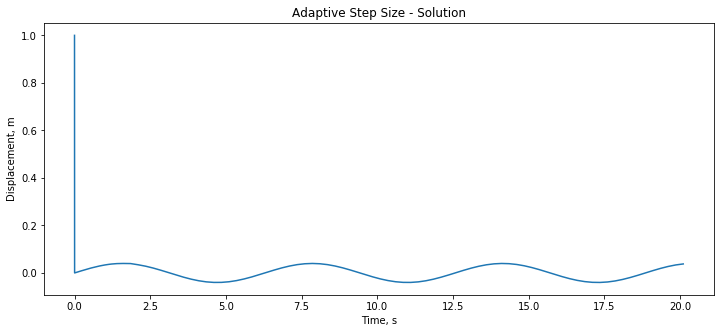

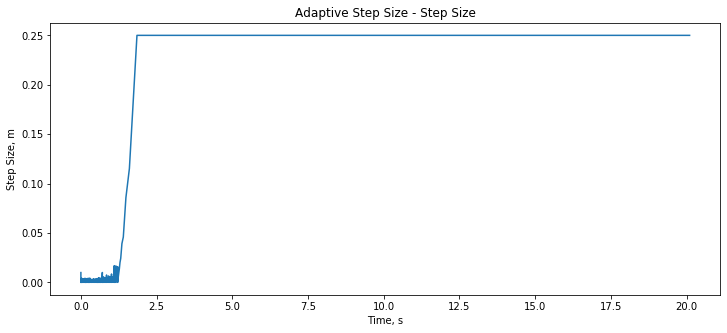

In [15]:
# Modular higher-accuracy function (for bonus RK2 implementation later)
def two_halves(f, x_n, t, h, tol=1e-4, iterations=50):
    x_n1_2, _, _ = nr_step_basic(f, x_n, t, h/2, tol, iterations)
    x_n1 = nr_step_basic(f, x_n1_2, t+(h/2), h/2, tol, iterations)
    return x_n1

# Euler's Backward with Adaptive Step Size
def euler_backward_adaptive(f, x0, t0, tf, h0, single_func=nr_step_basic, complex_func=two_halves, tol=1e-4, iterations=50):
    t_vals = [t0]
    x_vals = [x0]
    nr_iterations = []
    nr_convergence = []
    h_vals = [h0]
    errs = []
    h = h0
    
    while t_vals[-1] <= tf:
        single_step = single_func(f, x_vals[-1], t_vals[-1], h, tol, iterations)
        complex_step = complex_func(f, x_vals[-1], t_vals[-1], h, tol, iterations)
        # New step size based on estimated error
        err = abs(complex_step[0] - single_step[0])
        h *= np.sqrt(tol / (err + 1e-10))
        # Step size safety
        h = max(1e-7, min(h, 0.25))
        # Decision
        if err < tol:
            x_i1, nr_i, nr_c = complex_step
            x_vals.append(x_i1)
            nr_iterations.append(nr_i)
            nr_convergence.append(nr_c)
            h_vals.append(h)
            t_vals.append(t_vals[-1] + h)
            errs.append(err)
    
    return t_vals, x_vals, nr_iterations, nr_convergence, h_vals, errs

# Adaptive step size plots
h0 = 0.01
adaptive = euler_backward_adaptive(f, x0, t0, tf, h0, tol=1e-6)
plt.figure(figsize=(12,5))
plt.plot(adaptive[0], adaptive[1])
plt.xlabel("Time, s")
plt.ylabel("Displacement, m")
plt.title("Adaptive Step Size - Solution")
plt.show()
plt.figure(figsize=(12,5))
plt.plot(adaptive[0], adaptive[4])
plt.xlabel("Time, s")
plt.ylabel("Step Size, m")
plt.title("Adaptive Step Size - Step Size")
plt.show()

The step size starts small to accommodate the fast initial motion, then adapts to the slow moving forcing function!

## Performance Analysis

